<a href="https://colab.research.google.com/github/Mohamedhegazzy52/GBG-Tasks/blob/main/GBG_G%D9%90%D9%8CRU_AR_Preprocessin%26_SA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


# المكتبات الأساسية
!pip install --upgrade pandas numpy -qq

# مكتبات معالجة النصوص العربية
!pip install --upgrade pyarabic -qq
!pip install --upgrade arabic-reshaper -qq
!pip install --upgrade python-bidi -qq

# مكتبات التعلم العميق
!pip install --upgrade tensorflow -qq
!pip install --upgrade keras -qq

# مكتبات معالجة اللغة الطبيعية
!pip install --upgrade nltk -qq

# مكتبات التصور
!pip install --upgrade matplotlib -qq
#!pip install --upgrade seaborn

# مكتبات إضافية مفيدة لتحليل المشاعر العربي
!pip install --upgrade scikit-learn -qq
!pip install --upgrade emoji -qq


##1. استيراد المكتبات وتحميل البيانات

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import pickle

# مكتبات معالجة النصوص العربية
import arabic_reshaper
#from bidi.algorithm import get_display
import pyarabic.araby as araby

# مكتبات التعلم العميق
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# مكتبات NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer
from nltk.tokenize import word_tokenize

# تحميل stopwords العربية
nltk.download('stopwords')
arabic_stopwords = set(stopwords.words('arabic'))

# التصور
import matplotlib.pyplot as plt
import seaborn as sns


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saurabhshahane/arabic-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'arabic-classification' dataset.
Path to dataset files: /kaggle/input/arabic-classification


In [ ]:
data = pd.read_csv("/kaggle/input/arabic-classification/arabic_dataset_classifiction.csv/arabic_dataset_classifiction.csv")
data.head()

,text,targe
0,بين أستوديوهات ورزازات وصحراء مرزوكة وآثار ولي...,0
1,قررت النجمة الأمريكية أوبرا وينفري ألا يقتصر ع...,0
2,أخبارنا المغربية الوزاني تصوير الشملالي ألهب ا...,0
3,اخبارنا المغربية قال ابراهيم الراشدي محامي سعد...,0
4,تزال صناعة الجلود في المغرب تتبع الطريقة التقل...,0


In [ ]:
df = data.copy()
df.head()
df.shape

(111728, 2)

##2. استكشاف البيانات (EDA)

(111728, 2) 
-----------------------------------
                                                text  targe
0  بين أستوديوهات ورزازات وصحراء مرزوكة وآثار ولي...      0
1  قررت النجمة الأمريكية أوبرا وينفري ألا يقتصر ع...      0
2  أخبارنا المغربية الوزاني تصوير الشملالي ألهب ا...      0
3  اخبارنا المغربية قال ابراهيم الراشدي محامي سعد...      0
4  تزال صناعة الجلود في المغرب تتبع الطريقة التقل...      0 
----------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111728 entries, 0 to 111727
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    108789 non-null  object
 1   targe   111728 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.7+ MB
None 
----------------------------------
               targe
count  111728.000000
mean        2.620659
std         1.451010
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max         4.000000 
----------------

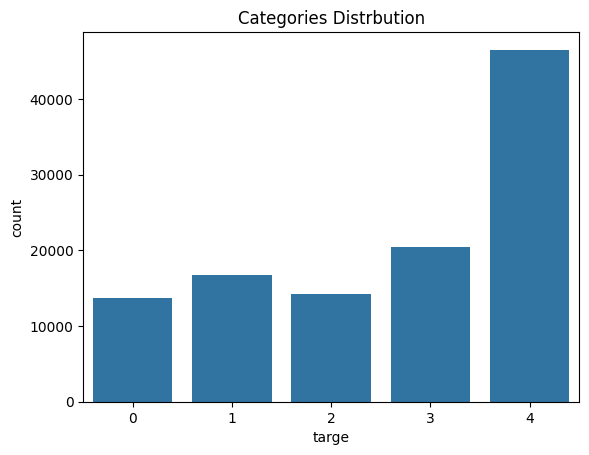

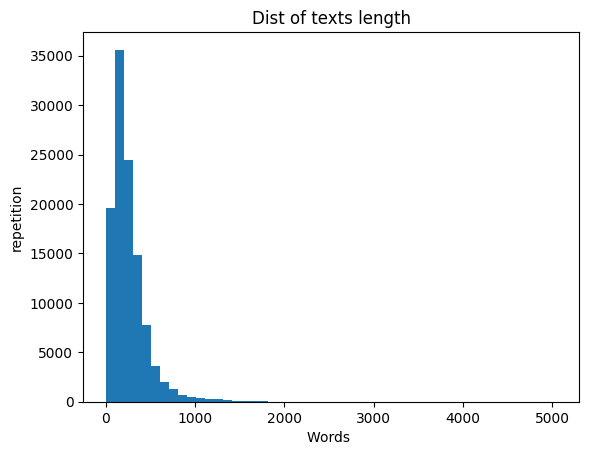

In [ ]:
# فحص البيانات
print(df.shape,"\n-----------------------------------")
print(df.head(),"\n----------------------------------")
print(df.info(),"\n----------------------------------")
print(df.describe(),"\n------------------------------")

# فحص القيم المفقودة
print(df.isnull().sum(),"\n--------------------------")

# فحص توزيع المشاعر
print(df['targe'].value_counts(),"\n-----------------")
sns.countplot(data=df, x='targe')
plt.title('Categories Distrbution')
plt.show()

# فحص طول النصوص
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
df['text_length'].describe()

# رسم توزيع الطول
plt.hist(df['text_length'], bins=50)
plt.xlabel('Words ')
plt.ylabel('repetition')
plt.title('Dist of texts length')
plt.show()

In [ ]:
df = df.drop(columns='text_length')

##3. معالجة القيم المفقودة



In [ ]:
# validate before cleaning
print(f" عدد النصوص الفارغة:\n {df.isnull().sum()}")
# حذف الصفوف التي تحتوي على قيم مفقودة في النص أو التصنيف
df = df.dropna(subset=['text', 'targe'])

# أو تعبئة القيم المفقودة بنص فارغ
#df['text'].fillna('', inplace=True)

# التحقق
print(df.isnull().sum())

 عدد النصوص الفارغة:
 text     2939
targe       0
dtype: int64
text     0
targe    0
dtype: int64


##4. معالجة القيم المكررة

In [ ]:
# عرض عدد الصفوف المكررة
print(f"عدد الصفوف المكررة: {df.duplicated().sum()}")

# حذف المكررات
df = df.drop_duplicates(subset=['text'], keep='first')

# إعادة ترتيب الفهرس
df = df.reset_index(drop=True)

print(f"عدد الصفوف بعد الحذف: {len(df)}")

عدد الصفوف المكررة: 3203
عدد الصفوف بعد الحذف: 105533


##5. تنظيف النصوص العربية


In [ ]:
def clean_arabic_text(text):
    """
    تنظيف شامل للنصوص العربية
    """
    if pd.isna(text) or text == '':
        return ''

    text = str(text)

    # 1. إزالة التشكيل (الفتحة، الضمة، الكسرة، إلخ)
    text = araby.strip_tashkeel(text)
    text = araby.strip_tatweel(text)  # إزالة التطويل (ـ)

    # 2. توحيد الهمزات
    text = re.sub("[إأٱآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)
    text = re.sub("ة", "ه", text)

    # 3. إزالة الأرقام الإنجليزية والعربية
    text = re.sub(r'\d+', '', text)
    text = re.sub('[٠-٩]', '', text)

    # 4. إزالة الرموز والعلامات
    text = re.sub(r'[^\w\s]', ' ', text)  # إزالة علامات الترقيم
    text = re.sub('[%s]' % re.escape(string.punctuation), ' ', text)

    # 5. إزالة الرموز الخاصة والإيموجي
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)

    # 6. إزالة الأحرف الإنجليزية
    text = re.sub(r'[a-zA-Z]+', '', text)

    # 7. إزالة المسافات المتعددة
    text = re.sub(r'\s+', ' ', text)

    # 8. إزالة الروابط
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 9. إزالة الإشارات (@username)
    text = re.sub(r'@\w+', '', text)

    # 10. إزالة الهاشتاجات
    text = re.sub(r'#\w+', '', text)

    # 11. تنظيف المسافات في البداية والنهاية
    text = text.strip()

    return text

# تطبيق التنظيف
df['text'] = df['text'].apply(clean_arabic_text)

# عرض مثال
print("قبل التنظيف:")
print(df['text'].iloc[0])
print("\nبعد التنظيف:")
print(df['text'].iloc[0])

قبل التنظيف:
بين استوديوهات ورزازات وصحراء مرزوكه واثار وليلي ثم الرباط والبيضاء انتهي المخرج المغربي سهيل بن بركه من تصوير مشاهد عمله السينماءي الجديد الذي خصصه لتسليط الضوء عن حياه الجاسوس الاسباني دومينغو باديا الذي عاش فتره من القرن التاسع عشر بالمغرب باسم علي باي هذا الفيلم الذي اختار له مخرجه عنوان حلم خليفه يصور حياه علي باي العباسي الذي ما زال احد احياء طنجه يحمل اسمه عاش حياه فريده متنكرا بشخصيه تاجر عربي من سلاله الرسول صلي الله عليه وسلم فيما كان يعمل جاسوسا لحساب اسبانيا وكشف مخرج الفيلم سهيل بن بركه في تصريح لهسبريس ان الفيلم السينماءي دخل مرحله التوضيب التي تتم خارج المغرب مبرزا ان الفيلم الذي يروي حياه الجاسوس الاسباني دومينغو باديا منذ ان قرر من طنجه بدء رحلاته نحو عدد من المناطق في العالم الاسلامي بدايه القرن العشرين سيكون جاهزا بعد شهرين ويجمع الفيلم السينماءي عددا من الممثلين من مختلف الجنسيات واختار لدور البطوله الممثله السينماءيه الايطاليه كارولينا كريشنتيني للقيام بدور الانجليزيه الليدي هستر ستانهوب التي اشتهرت في الكتب الغربيه ب زنوبيا والتي عاشت بدورها بالدول ال

##6. إزالة الكلمات الشائعة (Stop Words)

In [ ]:
# إضافة كلمات شائعة مخصصة
custom_stopwords = {'من', 'في', 'على', 'إلى', 'هذا', 'هذه', 'ذلك', 'التي', 'الذي'}
arabic_stopwords.update(custom_stopwords)

def remove_stopwords(text):
    """
    إزالة الكلمات الشائعة
    """
    if not text:
        return ''

    words = text.split()
    filtered_words = [word for word in words if word not in arabic_stopwords]
    return ' '.join(filtered_words)

df['text'] = df['text'].apply(remove_stopwords)

In [ ]:
df = df.drop(columns=['no_stopwords'])
df.head()

,text,targe
0,استوديوهات ورزازات وصحراء مرزوكه واثار وليلي ا...,0
1,قررت النجمه الامريكيه اوبرا وينفري الا يقتصر ع...,0
2,اخبارنا المغربيه الوزاني تصوير الشملالي الهب ا...,0
3,اخبارنا المغربيه قال ابراهيم الراشدي محامي سعد...,0
4,تزال صناعه الجلود المغرب تتبع الطريقه التقليدي...,0


In [ ]:
df.shape

(105533, 2)

##7. التجذير (Stemming) - اختياري

In [ ]:
# (ISRI Stemmer) AR Stemmer IF needed

stemmer = ISRIStemmer()

def stem_text(text):
    """
    تجذير النص العربي
    """
    if not text:
        return ''

    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return ' '.join(stemmed_words)

# يمكن تطبيقه أو تخطيه حسب الأداء
# df['stemmed_text'] = df['no_stopwords'].apply(stem_text)

# في معظم الحالات، نستخدم النص بدون تجذير لـ GRU
df['text'] = df['text']

##8. معالجة النصوص الفارغة

In [ ]:
# حذف النصوص التي أصبحت فارغة بعد التنظيف
df = df[df['text'].str.strip() != '']
df = df[df['text'].str.len() > 2]  # على الأقل 3 أحرف

# إعادة تعيين الفهرس
df = df.reset_index(drop=True)

print(f"عدد الصفوف بعد إزالة النصوص الفارغة: {len(df)}")

عدد الصفوف بعد إزالة النصوص الفارغة: 105530


##9. ترميز التصنيفات (Label Encoding)

In [ ]:
# Label Encoding for target
from sklearn.preprocessing import LabelEncoder

# ترميز المشاعر
le = LabelEncoder()
df['label'] = le.fit_transform(df['targe'])

# عرض التحويل
print("التحويل:")
for i, label in enumerate(le.classes_):
    print(f"{label} -> {i}")

# حفظ المشفر للاستخدام لاحقاً
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

التحويل:
0 -> 0
1 -> 1
2 -> 2
3 -> 3
4 -> 4


In [ ]:
# فحص التوازن
print(df['targe'].value_counts())

targe
4    42694
3    19778
1    15965
2    13695
0    13398
Name: count, dtype: int64


##10. معالجة عدم التوازن في البيانات

In [ ]:
# فحص التوازن
print(df['label'].value_counts())

label
4    42694
3    19778
1    15965
2    13695
0    13398
Name: count, dtype: int64


In [ ]:
# Using class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['label']),
    y=df['label']
)

class_weight_dict = dict(enumerate(class_weights))


أوزان الفئات: {0: np.float64(1.575309747723541), 1: np.float64(1.322016911994989), 2: np.float64(1.5411464037970062), 3: np.float64(1.0671453129740116), 4: np.float64(0.4943551787136366)}


##11. Tokenization وبناء المفردات

In [ ]:
# تحديد معاملات Tokenizer
MAX_WORDS = 50000  # حجم المفردات
MAX_LEN = 100      # طول التسلسل

# إنشاء Tokenizer
tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token='<OOV>',  # للكلمات غير الموجودة
    filters='',         # لا نريد فلترة إضافية لأننا نظفنا مسبقاً
)

# بناء المفردات
tokenizer.fit_on_texts(df['text'])

# تحويل النصوص لأرقام
sequences = tokenizer.texts_to_sequences(df['text'])

# Padding
X = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print(f"شكل البيانات: {X.shape}")
print(f"حجم المفردات: {len(tokenizer.word_index)}")

# # حفظ Tokenizer
# with open('tokenizer.pkl', 'wb') as f:
#     pickle.dump(tokenizer, f)

شكل البيانات: (105530, 100)
حجم المفردات: 388282


##12. تقسيم البيانات

In [ ]:
from sklearn.model_selection import train_test_split

# تحضير المتغيرات
y = df['label'].values

# التقسيم الأول: train+val و test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y  # للحفاظ على التوزيع
)

# التقسيم الثاني: train و validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.15,  # من الباقي
    random_state=42,
    stratify=y_temp
)

print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Validation: {X_val.shape}, {y_val.shape}")
print(f"Test: {X_test.shape}, {y_test.shape}")

# فحص التوزيع
print("\nتوزيع Train:")
print(pd.Series(y_train).value_counts())
print("\nتوزيع Validation:")
print(pd.Series(y_val).value_counts())
print("\nتوزيع Test:")
print(pd.Series(y_test).value_counts())

Train: (76245, 100), (76245,)
Validation: (13455, 100), (13455,)
Test: (15830, 100), (15830,)

توزيع Train:
4    30847
3    14289
1    11534
2     9895
0     9680
Name: count, dtype: int64

توزيع Validation:
4    5443
3    2522
1    2036
2    1746
0    1708
Name: count, dtype: int64

توزيع Test:
4    6404
3    2967
1    2395
2    2054
0    2010
Name: count, dtype: int64


##13. بناء نموذج GRU

In [ ]:
# معاملات النموذج
EMBEDDING_DIM = 128
GRU_UNITS = 128
DROPOUT_RATE = 0.3
NUM_CLASSES = len(le.classes_)

# بناء النموذج
model = Sequential([
    # Embedding Layer
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN,
        mask_zero=True  # تجاهل القيم المحشوة
    ),

    # Spatial Dropout
    SpatialDropout1D(DROPOUT_RATE),

    # Bidirectional GRU Layer 1
    Bidirectional(GRU(
        GRU_UNITS,
        return_sequences=True,
        dropout=DROPOUT_RATE,
        recurrent_dropout=0.2
    )),

    # Bidirectional GRU Layer 2
    Bidirectional(GRU(
        GRU_UNITS // 2,
        return_sequences=False,
        dropout=DROPOUT_RATE,
        recurrent_dropout=0.2
    )),

    # Dense Layers
    Dense(64, activation='relu'),
    Dropout(DROPOUT_RATE),

    Dense(32, activation='relu'),
    Dropout(DROPOUT_RATE),

    # Output Layer
    Dense(NUM_CLASSES, activation='softmax' if NUM_CLASSES > 2 else 'sigmoid')
])

# عرض ملخص النموذج
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

##14. تجميع النموذج

In [ ]:
# اختيار المحسن
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# تجميع النموذج
if NUM_CLASSES > 2:
    # Multi-class classification
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
else:
    # Binary classification
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

##15. إعداد Callbacks

In [ ]:
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Model Checkpoint
checkpoint = ModelCheckpoint(
    'best_gru_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stop, reduce_lr, checkpoint]

##16. تدريب النموذج

In [ ]:
# تدريب
EPOCHS = 3
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,  # استخدام الأوزان
    callbacks=callbacks,
    verbose=1
)

Epoch 1/3
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7357 - loss: 0.7282
Epoch 1: val_accuracy improved from None to 0.95340, saving model to best_gru_model.h5



Epoch 1: finished saving model to best_gru_model.h5
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 1564s 1s/step - accuracy: 0.8686 - loss: 0.4340 - val_accuracy: 0.9534 - val_loss: 0.1492 - learning_rate: 0.0010
Epoch 2/3
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9637 - loss: 0.1664
Epoch 2: val_accuracy did not improve from 0.95340
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 1419s 1s/step - accuracy: 0.9631 - loss: 0.1623 - val_accuracy: 0.9515 - val_loss: 0.1621 - learning_rate: 0.0010
Epoch 3/3
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9794 - loss: 0.0904
Epoch 3: val_accuracy did not improve from 0.95340
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 1402s 1s/step - accuracy: 0.9776 - loss: 0.0992 - val_accuracy: 0.9471 - val_loss: 0.1868 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.


##17. تصور نتائج التدريب

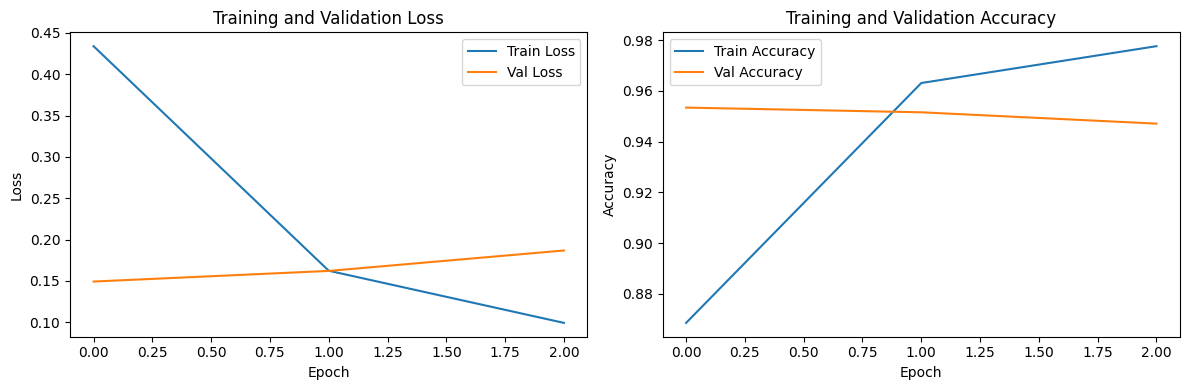

In [ ]:
# رسم Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

# رسم Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.tight_layout()
plt.show()

##18. تقييم النموذج

495/495 ━━━━━━━━━━━━━━━━━━━━ 73s 148ms/step
Test Accuracy: 0.9546

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      2010
           1       0.96      0.97      0.96      2395
           2       0.90      0.90      0.90      2054
           3       0.93      0.89      0.91      2967
           4       0.99      0.99      0.99      6404

    accuracy                           0.95     15830
   macro avg       0.94      0.94      0.94     15830
weighted avg       0.95      0.95      0.95     15830



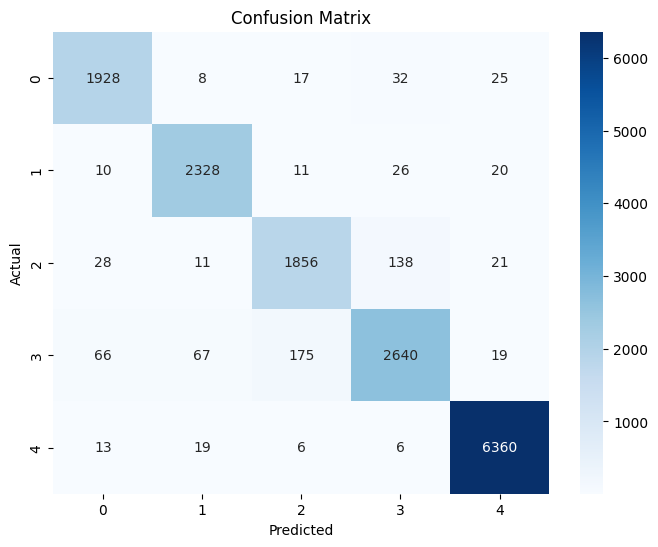

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# التنبؤ على مجموعة الاختبار
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1) if NUM_CLASSES > 2 else (y_pred_probs > 0.5).astype(int)

# Accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
# Convert numerical labels to strings for target_names
string_target_names = [str(label) for label in le.classes_]
print(classification_report(y_test, y_pred, target_names=string_target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=string_target_names, yticklabels=string_target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

##19. حفظ النموذج

In [ ]:
# حفظ النموذج الكامل
model.save('arabic_sentiment_gru_model.h5')

# حفظ الأوزان فقط
model.save_weights('gru_weights.weights.h5')

# حفظ المعاملات
config = {
    'max_words': MAX_WORDS,
    'max_len': MAX_LEN,
    'embedding_dim': EMBEDDING_DIM,
    'gru_units': GRU_UNITS,
    'num_classes': NUM_CLASSES
}

with open('model_config.pkl', 'wb') as f:
    pickle.dump(config, f)

##20. التنبؤ على نصوص جديدة

In [ ]:
def predict_sentiment(text):
    """
    التنبؤ بمشاعر نص جديد
    """
    # تنظيف النص
    cleaned = clean_arabic_text(text)
    cleaned = remove_stopwords(cleaned)

    # تحويل لأرقام
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # التنبؤ
    pred_probs = model.predict(padded, verbose=0)

    if NUM_CLASSES > 2:
        pred_class = np.argmax(pred_probs, axis=1)[0]
        confidence = pred_probs[0][pred_class]
    else:
        pred_class = (pred_probs[0][0] > 0.5).astype(int)
        confidence = pred_probs[0][0] if pred_class == 1 else 1 - pred_probs[0][0]

    sentiment = le.inverse_transform([pred_class])[0]

    return {
        'text': text,
        'sentiment': sentiment,
        'confidence': float(confidence),
        'all_probabilities': {le.classes_[i]: float(pred_probs[0][i])
                             for i in range(NUM_CLASSES)}
    }

# مثال
test_text =input("..هذا المنتج رائع جداً وأنصح به بشدة؟.")
result = predict_sentiment(test_text)
print(result)

..هذا المنتج رائع جداً وأنصح به بشدة؟.ما اجمل السماء
{'text': 'ما اجمل السماء', 'sentiment': np.int64(3), 'confidence': 0.29872339963912964, 'all_probabilities': {np.int64(0): 0.16598132252693176, np.int64(1): 0.20017828047275543, np.int64(2): 0.23044809699058533, np.int64(3): 0.29872339963912964, np.int64(4): 0.10466893017292023}}


In [ ]:
########################################################################

In [ ]:
from datasets import load_dataset

ds = load_dataset("mohamedadaly/labr")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/3.83M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/919k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11760 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2935 [00:00<?, ? examples/s]

In [ ]:
from datasets import load_dataset

dataset = load_dataset("mohamedadaly/labr")

In [ ]:


# or load the separate splits if the dataset has train/validation/test splits
train_dataset = load_dataset("mohamedadaly/labr", split="train")


In [ ]:
df = train_dataset.to_pandas()
df.head()

,text,label
0,هى رواية مملة لابعد الحدود مفيهاش اى حاجة تشد...,0
1,بدأت قِراءة الصفحات الأولى على نغمات فيفالدي ...,0
2,أول مرة اكتب انطباعي عن كتاب قبل ان أنتهي حتي...,0
3,خيالية جدًا . ماحبيتها الصراحة,0
4,"ولاني ما أتقن قراءة ما بين السطور , ما استسغت...",0


In [ ]:
df.head()

,text,label
0,هى رواية مملة لابعد الحدود مفيهاش اى حاجة تشد...,0
1,بدأت قِراءة الصفحات الأولى على نغمات فيفالدي ...,0
2,أول مرة اكتب انطباعي عن كتاب قبل ان أنتهي حتي...,0
3,خيالية جدًا . ماحبيتها الصراحة,0
4,"ولاني ما أتقن قراءة ما بين السطور , ما استسغت...",0


In [ ]:
df.shape

(11760, 2)

In [ ]:
import re

def clean_text(text):
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    text = re.sub(r'\s+', ' ', text) # Replace one or more whitespace characters with a single space
    text = text.strip() # Remove leading/trailing whitespace
    return text

df['text'] = df['text'].apply(clean_text)

df.head(3)

,text,label
0,هى رواية مملة لابعد الحدود مفيهاش اى حاجة تشد ...,0
1,بدأت قراءة الصفحات الأولى على نغمات فيفالدي ثم...,0
2,أول مرة اكتب انطباعي عن كتاب قبل ان أنتهي حتي ...,0


In [ ]:
#remove numbers
df['text'] = df['text'].apply(lambda x: re.sub(r'\d+', '', x))
df.head()

,text,label
0,هى رواية مملة لابعد الحدود مفيهاش اى حاجة تشد ...,0
1,بدأت قراءة الصفحات الأولى على نغمات فيفالدي ثم...,0
2,أول مرة اكتب انطباعي عن كتاب قبل ان أنتهي حتي ...,0
3,خيالية جدا ماحبيتها الصراحة,0
4,ولاني ما أتقن قراءة ما بين السطور ما استسغتها ...,0


In [ ]:
# ===== Regex Patterns =====
DIACRITICS = re.compile(r'[\u0617-\u061A\u064B-\u0652\u0670]')
TATWEEL = re.compile(r'\u0640')


def remove_diacritics(text):
    """إزالة التشكيل"""
    return DIACRITICS.sub('', df['text'])


def remove_tatweel(text):
    """إزالة الكشيدة"""
    return TATWEEL.sub('', text)


def remove_elongation(text):
    """حلوووو → حلو"""
    return re.sub(r'(.)\1{2,}', r'\1', text)


def remove_urls(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)


def remove_mentions_hashtags(text):
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    return text


def remove_emojis(text):
    return re.compile(
        "[" "\U0001F600-\U0001F64F" "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF" "\U0001F1E0-\U0001F1FF"
        "\U00002500-\U00002BEF" "\U00002702-\U000027B0"
        "\U00010000-\U0010ffff" "]+", flags=re.UNICODE
    ).sub('', text)


def remove_english(text):
    return re.sub(r'[a-zA-Z]', '', text)


def remove_numbers(text):
    return re.sub(r'[0-9٠-٩]+', '', text)


def remove_punctuation(text):
    arabic_punct = '؟،؛«»'
    all_punct = string.punctuation + arabic_punct + '…–—'
    return text.translate(str.maketrans('', '', all_punct))


def normalize_arabic(text):
    """توحيد الحروف"""
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    return text


def remove_extra_whitespace(text):
    return re.sub(r'\s+', ' ', text).strip()


print('✅ All cleaning functions defined!')

,text,label
0,هى رواية مملة لابعد الحدود مفيهاش اى حاجة تشد ...,0
1,بدأت قراءة الصفحات الأولى على نغمات فيفالدي ثم...,0
2,أول مرة اكتب انطباعي عن كتاب قبل ان أنتهي حتي ...,0
3,خيالية جدا ماحبيتها الصراحة,0
4,ولاني ما أتقن قراءة ما بين السطور ما استسغتها ...,0
